<a href="https://colab.research.google.com/github/Ripazha05/Probabilitas-dan-Statistika/blob/main/Probabilitas_Dan_Statistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        ID                Name  Kuis  UTS  UAS  Nilai Akhir Nilai Huruf
0   120001            John Doe    85   78   90    84.333333           A
1   120005          Jane Smith    92   88   94    91.333333           A
2   120017     Michael Johnson    48   65   56    56.333333           D
3   120018         Emily Brown    90   85   88    87.666667           A
4   120022     Daniel Martinez    75   80   77    77.333333           B
5   120024        Sarah Wilson    88   70   65    74.333333           B
6   120025        David Garcia    75   70   75    73.333333           B
7   120027         Jessica Lee    95   91   96    94.000000           A
8   120034       Matthew Davis    79   84   78    80.333333           A
9   120035  Jennifer Rodriguez    42   48   63    51.000000           D
10  120036       Andrew Taylor    53   64   59    58.666667           D
11  120038    Amanda Hernandez    91   95   90    92.000000           A
12  120039   Christopher Clark    76   81   75    77.333333     

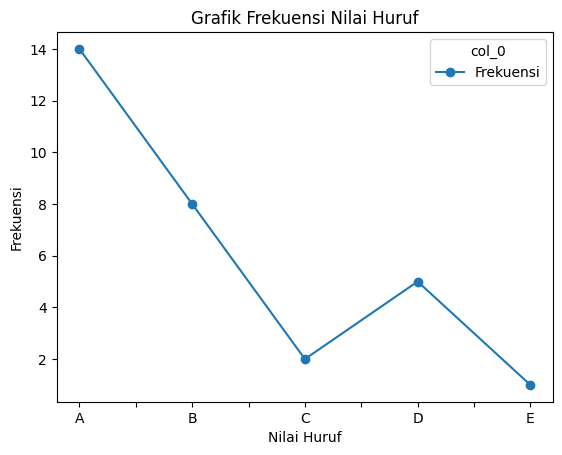

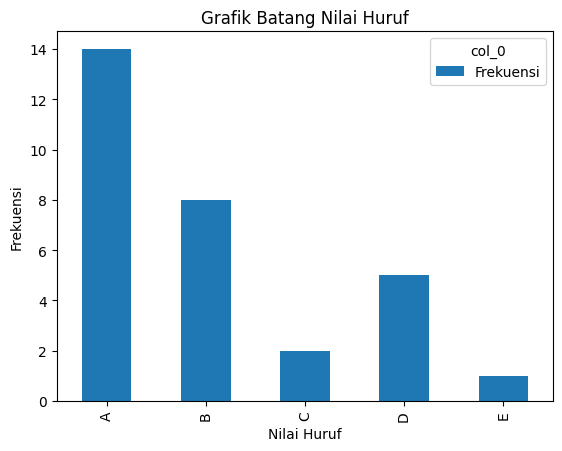

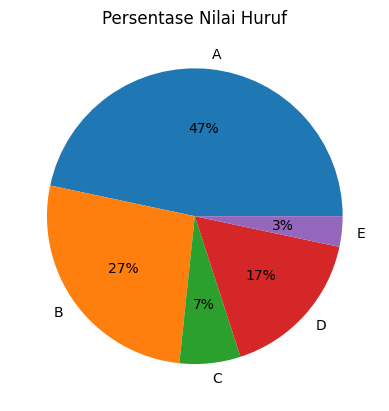

count              30.000000
mean               76.233333
std                13.477994
min                46.000000
25%                68.083333
50%                78.833333
75%                87.083333
max                94.000000
Standard Error      2.460734
Median             78.833333
Mode               77.333333
Variance          181.656322
Range              48.000000
Skewness           -0.672946
Kurtosis           -0.513549
Name: Nilai Akhir, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tabel Data
path = "/Rifa data.xlsx"

dataraw = pd.read_excel(path, header=6)

# Drop the 'Unnamed: 0' column if it exists and contains all null values,
# as it's likely an artifact from the Excel import.
if 'Unnamed: 0' in dataraw.columns and dataraw['Unnamed: 0'].isnull().all():
    dataraw = dataraw.drop(columns=['Unnamed: 0'])

# Mengganti nama kolom agar lebih mudah digunakan
dataraw.columns = [
    "ID",
    "Name",
    "Kuis",
    "UTS",
    "UAS",
    "Nilai Akhir",
    "Nilai Huruf"
]

# Calculate 'Nilai Akhir' as the average of 'Kuis', 'UTS', and 'UAS'
dataraw["Nilai Akhir"] = dataraw[["Kuis", "UTS", "UAS"]].mean(axis=1)

# Calculate 'Nilai Huruf' based on 'Nilai Akhir'
def assign_grade(score):
    if score >= 80:
        return "A"
    elif score >= 70:
        return "B"
    elif score >= 60:
        return "C"
    elif score >= 50:
        return "D"
    else:
        return "E"

dataraw["Nilai Huruf"] = dataraw["Nilai Akhir"].apply(assign_grade)

print(dataraw)

# Tabel Frekuensi
datafrq = pd.crosstab(
    index=dataraw["Nilai Huruf"],
    columns="Frekuensi"
)

print(datafrq)

# Grafik Garis
datafrq.plot(marker="o")

plt.title("Grafik Frekuensi Nilai Huruf")
plt.xlabel("Nilai Huruf")
plt.ylabel("Frekuensi")
plt.show()

# Grafik Batang
datafrq.plot(kind="bar")

plt.title("Grafik Batang Nilai Huruf")
plt.xlabel("Nilai Huruf")
plt.ylabel("Frekuensi")
plt.show()

# Pie Chart
datafrq.plot(
    kind="pie",
    y="Frekuensi",
    autopct="%1.0f%%",
    legend=False
)

plt.title("Persentase Nilai Huruf")
plt.ylabel("")
plt.show()

# Statistika Deskriptif
dataraw["Nilai Akhir"] = pd.to_numeric(
    dataraw["Nilai Akhir"],
    errors="coerce"
)

dt = dataraw["Nilai Akhir"]

stats = dt.describe()

stats["Standard Error"] = dt.sem()
stats["Median"] = dt.median()
stats["Mode"] = dt.mode()[0]
stats["Variance"] = dt.var()
stats["Range"] = dt.max() - dt.min()
stats["Skewness"] = dt.skew()
stats["Kurtosis"] = dt.kurtosis()

print(stats)